In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math

In [2]:
regression_models = {
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors=5)
}

In [3]:
data1 = pd.read_csv('miami-housing.csv')
data1 = data1.rename(columns={'SALE_PRC':'PRICE'})
data1

,LATITUDE,LONGITUDE,PARCELNO,PRICE,LND_SQFOOT,TOT_LVG_AREA,SPEC_FEAT_VAL,RAIL_DIST,OCEAN_DIST,WATER_DIST,CNTR_DIST,SUBCNTR_DI,HWY_DIST,age,avno60plus,month_sold,structure_quality
0,25.891031,-80.160561,622280070620,440000.0,9375,1753,0,2815.9,12811.4,347.6,42815.3,37742.2,15954.9,67,0,8,4
1,25.891324,-80.153968,622280100460,349000.0,9375,1715,0,4359.1,10648.4,337.8,43504.9,37340.5,18125.0,63,0,9,4
2,25.891334,-80.153740,622280100470,800000.0,9375,2276,49206,4412.9,10574.1,297.1,43530.4,37328.7,18200.5,61,0,2,4
3,25.891765,-80.152657,622280100530,988000.0,12450,2058,10033,4585.0,10156.5,0.0,43797.5,37423.2,18514.4,63,0,9,4
4,25.891825,-80.154639,622280100200,755000.0,12800,1684,16681,4063.4,10836.8,326.6,43599.7,37550.8,17903.4,42,0,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13927,25.783130,-80.259795,131320040990,275000.0,6780,967,6580,3844.5,20568.0,3252.4,22175.9,12150.1,917.4,16,0,4,4
13928,25.783585,-80.260354,131320040910,340000.0,7500,1854,2544,3593.6,20791.9,3077.7,22375.1,12316.8,738.2,26,0,5,4
13929,25.783793,-80.256126,131320040420,287500.0,8460,1271,2064,4143.2,20307.9,3588.4,20966.9,12433.0,743.7,16,0,7,4
13930,25.784007,-80.257542,131320040330,315000.0,7500,1613,3136,3986.9,20542.6,3589.1,21475.6,12458.0,626.1,16,0,8,4


In [4]:
model_Volume = smf.ols(formula='PRICE ~ month_sold', data=data1).fit()
print(model_Volume.summary())
    

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.001468
Date:                Wed, 01 Apr 2026   Prob (F-statistic):              0.969
Time:                        18:26:29   Log-Likelihood:            -1.9625e+05
No. Observations:               13932   AIC:                         3.925e+05
Df Residuals:                   13930   BIC:                         3.925e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.997e+05   6048.256     66.091      0.0

In [5]:
X = data1.drop(columns=['PRICE','PARCELNO','month_sold'])
y = data1['PRICE']

# prepare datasets for model training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
results = {}

for name, model in regression_models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results[name] = (rmse, r2)

    print(f"{name}")
    print(f"RMSE: {round(rmse,4)}")
    print(f"R2 Score: {round(r2,4)}")
    print("----------------------------")

DecisionTreeRegressor
RMSE: 127504.6193
R2 Score: 0.8349
----------------------------
RandomForestRegressor
RMSE: 97473.7742
R2 Score: 0.9035
----------------------------
KNeighborsRegressor
RMSE: 134586.6049
R2 Score: 0.816
----------------------------


In [7]:
best_model = max(results, key=lambda x: results[x][1])

print("Best model:", best_model)
print("Highest R2:", results[best_model][1])

Best model: RandomForestRegressor
Highest R2: 0.9035123430823832


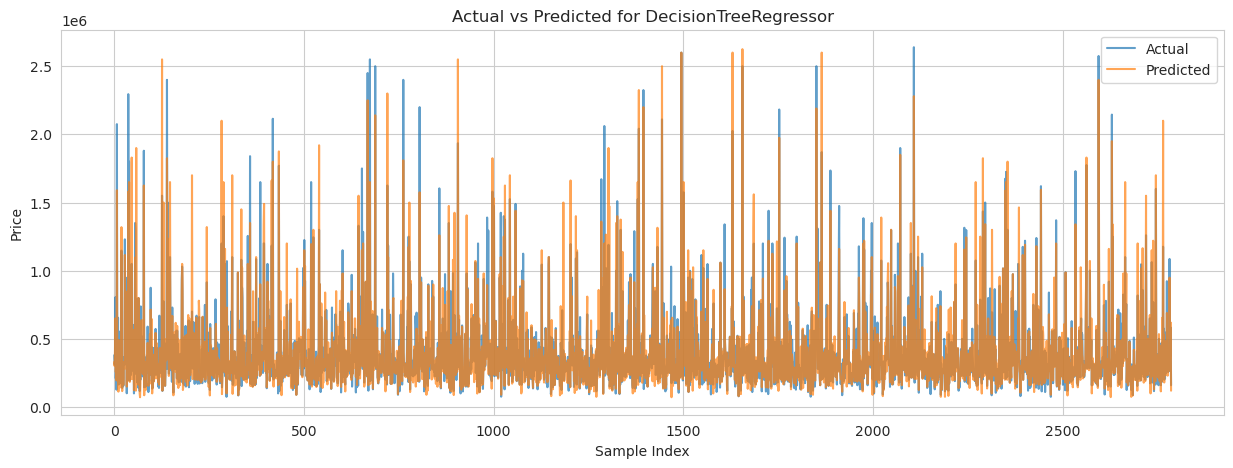

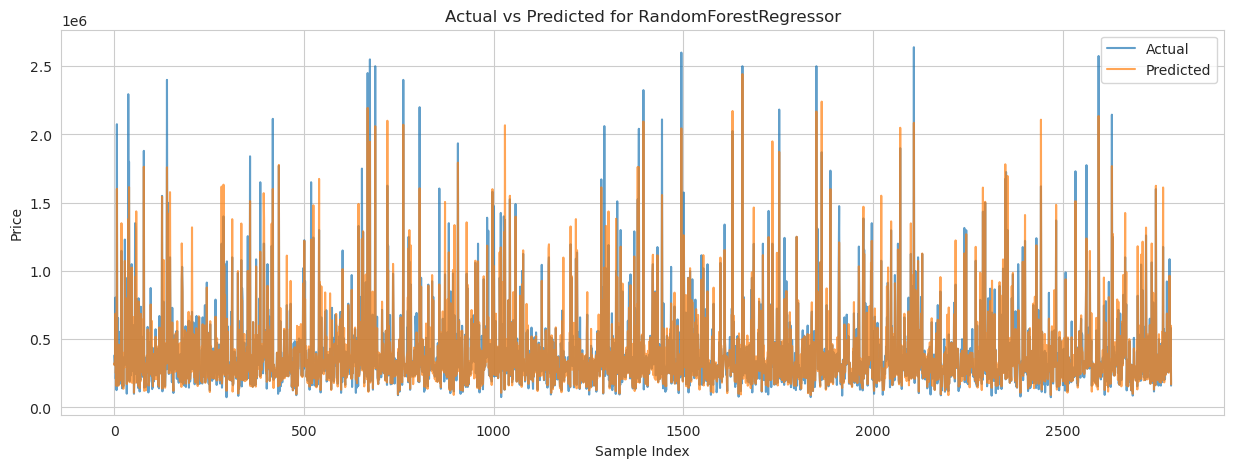

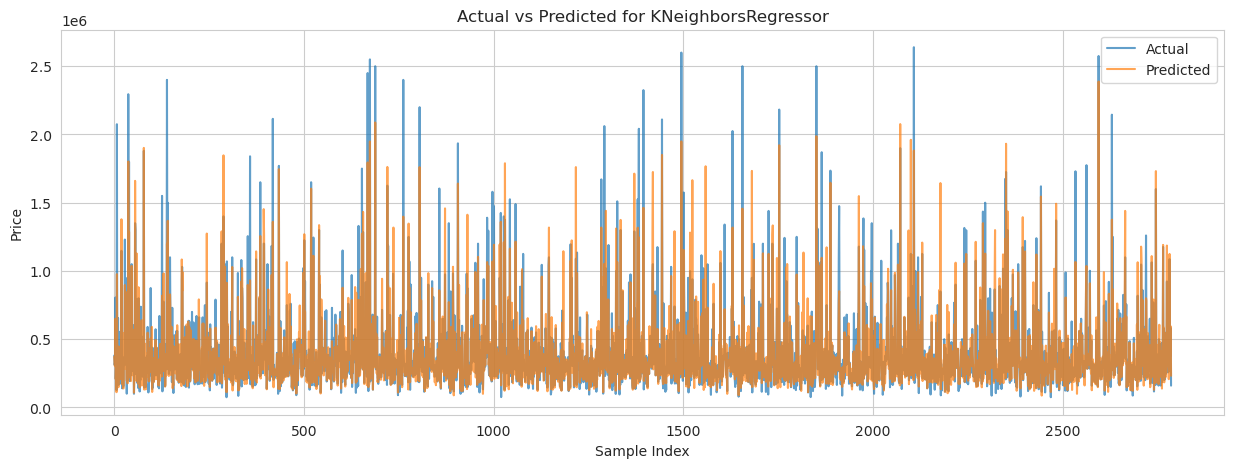

In [8]:
for name, model in regression_models.items():

    preds = model.predict(X_test)

    plt.figure(figsize=(15,5))
    plt.plot(y_test.values, label="Actual", alpha=0.7)
    plt.plot(preds, label="Predicted", alpha=0.7)

    plt.title(f"Actual vs Predicted for {name}")
    plt.xlabel("Sample Index")
    plt.ylabel("Price")
    plt.legend()

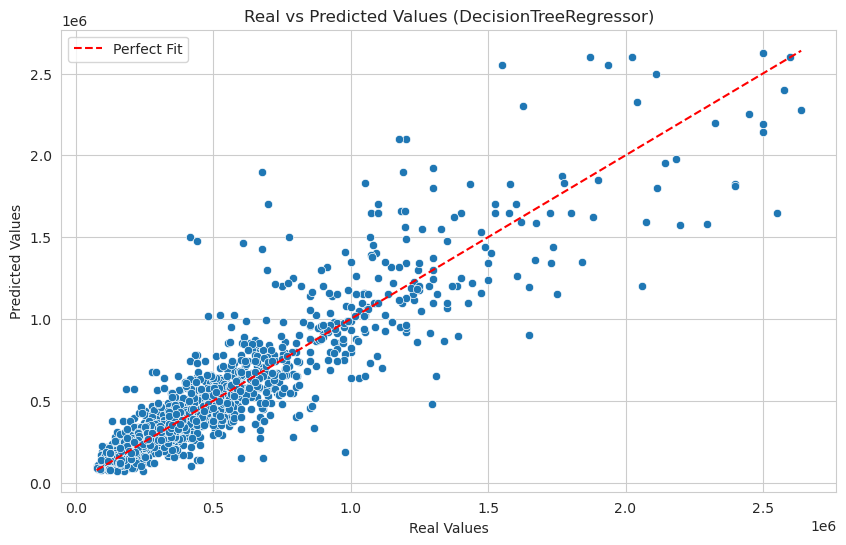

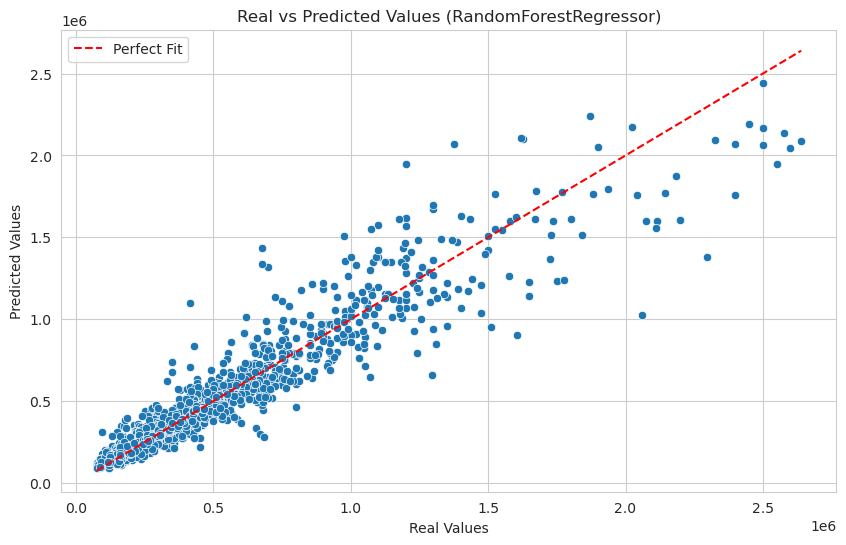

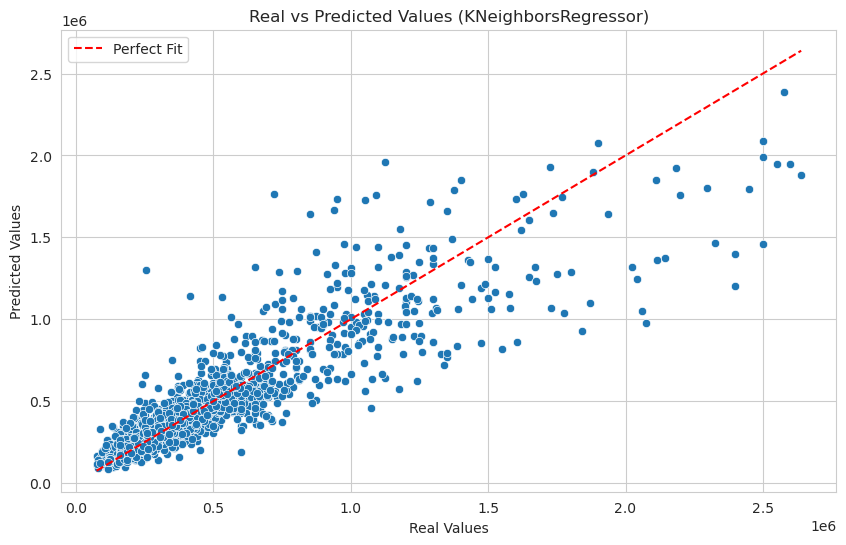

In [9]:
for name, model in regression_models.items():

    preds = model.predict(X_test)

    plt.figure(figsize=(10,6))

    sns.scatterplot(x=y_test, y=preds)

    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', label="Perfect Fit")

    plt.title(f"Real vs Predicted Values ({name})")
    plt.xlabel("Real Values")
    plt.ylabel("Predicted Values")

    plt.legend()
    plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

In [11]:
data1.loc[data1["PRICE"]>data1["PRICE"].mean(),"HIGHER_AVG"]=1
data1.loc[data1["PRICE"]<data1["PRICE"].mean(),"HIGHER_AVG"] =0

In [12]:
X = data1.drop(columns=['PRICE','PARCELNO','avno60plus','LATITUDE','LONGITUDE'])
y = data1['HIGHER_AVG']

# prepare datasets for model training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
classification_models = {
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=5),
    "RandomForestClassifier":RandomForestClassifier(n_estimators=5),
    "LogisticRegression": LogisticRegression(max_iter=1000)
}

KNeighborsClassifier
Precision: 0.8711
Recall: 0.8447
F1 Score: 0.8577
-------------------------
RandomForestClassifier
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
-------------------------


/home/scsa/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression
Precision: 0.969
Recall: 0.9854
F1 Score: 0.9771
-------------------------


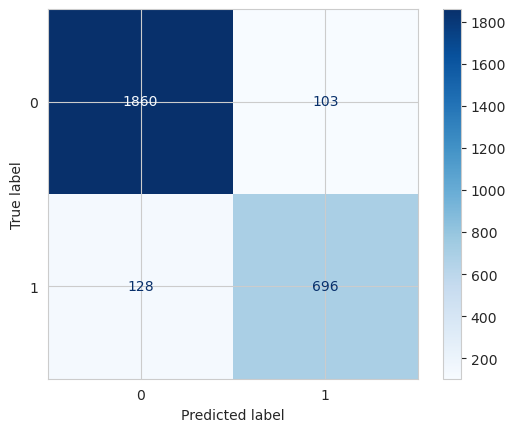

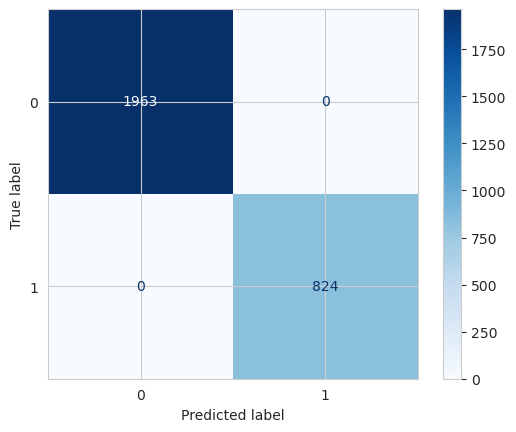

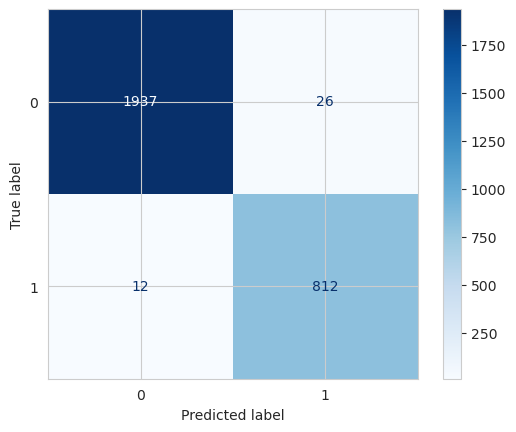

In [14]:
for name, model in classification_models.items():

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(name)
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1 Score:", round(f1,4))
    print("-------------------------")

    cm_model = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_model)
    disp.plot(cmap="Blues")